<b>Experiment: Generate new data with CTGAN, version 2: certain part of distribution</b>

Technically you can force any distribution to any shape you want. 

The problem is that this way we usually destroy the authenticity of the data, and the data connections, trends etc. might no longer make sense for a machine learning algorithm.

This means, if you force the distribution to a shape, you might actually make the metrics go worse.

In [1]:
# NOTE: installation takes time!
# pip install ctgan pandas
# pip install imblearn

import pandas as pd
from imblearn.under_sampling import RandomUnderSampler
import seaborn as sns
from ctgan import CTGAN

pd.set_option('display.float_format', '{:.1f}'.format)
df = pd.read_csv("../houses.csv")
df = df.drop(["id", "date", "zipcode", "lat", "long"], axis=1)
df

,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,grade,sqft_above,sqft_basement,yr_built,yr_renovated,sqft_living15,sqft_lot15
0,221900.0,3,1.0,1180,5650,1.0,0,0,3,7,1180,0,1955,0,1340,5650
1,538000.0,3,2.2,2570,7242,2.0,0,0,3,7,2170,400,1951,1991,1690,7639
2,180000.0,2,1.0,770,10000,1.0,0,0,3,6,770,0,1933,0,2720,8062
3,604000.0,4,3.0,1960,5000,1.0,0,0,5,7,1050,910,1965,0,1360,5000
4,510000.0,3,2.0,1680,8080,1.0,0,0,3,8,1680,0,1987,0,1800,7503
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
21608,360000.0,3,2.5,1530,1131,3.0,0,0,3,8,1530,0,2009,0,1530,1509
21609,400000.0,4,2.5,2310,5813,2.0,0,0,3,8,2310,0,2014,0,1830,7200
21610,402101.0,2,0.8,1020,1350,2.0,0,0,3,7,1020,0,2009,0,1020,2007
21611,400000.0,3,2.5,1600,2388,2.0,0,0,3,8,1600,0,2004,0,1410,1287


In [2]:
target = "price"

# we want to generate data only for the part of distribution 
# where price is over 1.5 million
subset_df = df[df['price'] > 1500000]

# typical X/y split, choose target variable as needed
X = df.drop([target], axis=1)
y = df[target]

# data = X.copy()
# data[target] = y

ctgan = CTGAN()
ctgan.fit(subset_df, epochs=100)

num_new_data = 10000
synthetic_df = ctgan.sample(num_new_data)

In [3]:
# combine with original data
df = pd.concat([df, synthetic_df])

<Axes: xlabel='price', ylabel='Count'>

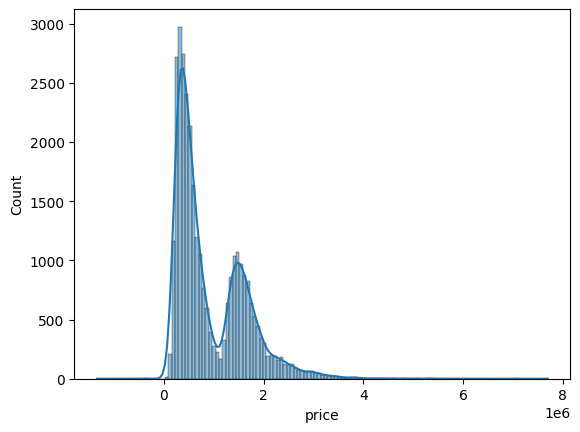

In [4]:
# we can now see the second "bump", that's where the new data is
sns.histplot(data=df, x="price", kde=True)

In [5]:
df.describe()

,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,grade,sqft_above,sqft_basement,yr_built,yr_renovated,sqft_living15,sqft_lot15
count,31613.0,31613.0,31613.0,31613.0,31613.0,31613.0,31613.0,31613.0,31613.0,31613.0,31613.0,31613.0,31613.0,31613.0,31613.0,31613.0
mean,927347.4,3.5,2.8,3097.4,10614.7,1.5,0.1,0.7,3.4,8.6,2325.9,572.3,1969.2,178.9,2670.8,14933.6
std,707042.2,1.0,1.4,1938.5,44836.9,0.6,0.4,1.2,0.7,1.9,1230.8,776.3,31.8,565.5,1276.2,36930.8
min,-1341350.1,0.0,0.0,290.0,-738714.0,0.6,0.0,-1.0,1.0,1.0,290.0,-818.0,1860.0,-141.0,399.0,-441369.0
25%,379500.0,3.0,1.8,1650.0,2850.0,1.0,0.0,0.0,3.0,7.0,1330.0,0.0,1948.0,0.0,1640.0,5695.0
50%,624000.0,3.0,2.5,2460.0,6650.0,1.5,0.0,0.0,3.0,8.0,2000.0,167.0,1974.0,0.0,2280.0,8640.0
75%,1456147.6,4.0,3.5,4169.0,10125.0,2.0,0.0,1.0,4.0,10.0,3095.0,964.0,1996.0,0.0,3567.0,15599.0
max,7700000.0,33.0,10.0,17785.0,1651359.0,3.7,1.0,5.0,6.0,15.0,10096.0,7113.0,2053.0,2644.0,8093.0,1423692.0
